## Business Problem

#### Background

RiverCity Public Library receives many patron service requests every day through online forms, emails, and digital platforms. These requests cover a variety of topics such as book availability, study room reservations, event registrations, digital access issues, staff assistance, and facility-related concerns. As the number of requests increases, library staff must manually read each message and determine which department should handle it. This process can be time-consuming and may lead to delays or incorrect routing of requests.

#### Business Problem

The goal of this project is to build a text classification model that can automatically categorize patron messages into the correct service request category based on the text content of the message.

The model will classify requests into one of the following categories:

* Book_Availability
* Study_Space
* Event_Registration
* Digital_Access
* Staff_Help
* Facility_Issue
  
#### Why This Problem Is Useful for the Business

This text classification system can provide several benefits to the public library:

* Faster Response Times: Requests can be automatically routed to the correct department without manual review.
* Improved Customer Service: Patrons receive assistance more quickly because requests reach the appropriate staff members immediately.
* Reduced Staff Workload: Employees spend less time sorting and categorizing messages and more time solving patron issues.
* Higher Operational Efficiency: The library can manage a large number of requests more effectively.
* Better Resource Allocation: Management can analyze request categories to identify common service issues and improve library operations.

#### Objective

The objective of this NLP project is to develop a machine learning model that analyzes patron messages and accurately predicts the correct request category. This will help RiverCity Public Library automate service request management and improve the overall patron experience.

## Task 1: Load and Inspect the Dataset

In [7]:
import pandas as pd
import numpy as np

df = pd.read_excel("NLP_Dataset_12_Public_Library_Service_Request.xlsx")

df.head()

,RequestID,RequestDate,Channel,City,Branch,PatronType,PatronMessage,RequestCategory,Priority
0,LIB-001,2026-04-06,Email,Toronto,West Branch,Parent,The online newspaper portal worked perfectly a...,Digital_Access,High
1,LIB-002,2026-04-10,Chat,Markham,West Branch,Senior,I liked the quiet study area in Markham; it he...,Study_Space,Medium
2,LIB-003,2026-04-14,Front Desk,Vaughan,West Branch,Researcher,There was a strong noise from construction dur...,Facility_Issue,High
3,LIB-004,2026-04-18,Mobile App,Vaughan,Campus Branch,New Member,The Wi-Fi at the branch in Vaughan disconnecte...,Digital_Access,High
4,LIB-005,2026-04-22,Website Form,Markham,Campus Branch,Student,A librarian explained the catalogue search in ...,Staff_Help,Medium


In [2]:
df.shape

(120, 9)

In [3]:
df.columns

Index(['RequestID', 'RequestDate', 'Channel', 'City', 'Branch', 'PatronType',
       'PatronMessage', 'RequestCategory', 'Priority'],
      dtype='object')

In [5]:
df.isnull().sum()

RequestID          0
RequestDate        0
Channel            0
City               0
Branch             0
PatronType         0
PatronMessage      0
RequestCategory    0
Priority           0
dtype: int64

In [45]:
df["RequestCategory"].value_counts()

RequestCategory
Digital_Access        20
Study_Space           20
Facility_Issue        20
Staff_Help            20
Event_Registration    20
Book_Availability     20
Name: count, dtype: int64

The dataset contains 120 rows and 9 columns, indicating there are 120 library service requests available for analysis. The dataset includes information about the request details, patron information, and the request category.

The dataset columns are:

* RequestID – Unique identifier for each request.
* RequestDate – Date when the request was submitted.
* Channel – Communication channel used to submit the request (Email, Chat, Mobile App, etc.).
* City – City associated with the patron.
* Branch – Library branch related to the request.
* PatronType – Type of patron (Student, Parent, Senior, Researcher, etc.).
* PatronMessage – Text message describing the patron's request. This is the main text column used for NLP analysis.
* RequestCategory – Category of the request. This is the target variable that the model will predict.
* Priority – Priority level assigned to the request.

The first few rows show sample patron requests and their corresponding categories. The missing value analysis indicates that there are no missing values in the dataset, which means the data is complete and ready for preprocessing.

The target variable distribution shows that all six request categories contain 20 records each, indicating that the dataset is balanced. A balanced dataset helps reduce bias during model training and allows the classifier to learn each category equally well.

The most important columns for this project are PatronMessage and RequestCategory. The PatronMessage column contains the text data used for NLP processing, while RequestCategory is the label that the machine learning model learns to predict. The balanced distribution of categories makes the dataset suitable for building a text classification model.

## Task 2: Text Preprocessing

In [8]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/trangnhungnguyen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/trangnhungnguyen/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/trangnhungnguyen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [10]:
df["Clean_Text"] = df["PatronMessage"].apply(clean_text)

df[["PatronMessage","Clean_Text"]].head()

,PatronMessage,Clean_Text
0,The online newspaper portal worked perfectly a...,online newspaper portal worked perfectly staff...
1,I liked the quiet study area in Markham; it he...,liked quiet study area markham helped prepare ...
2,There was a strong noise from construction dur...,strong noise construction visit rivercity libr...
3,The Wi-Fi at the branch in Vaughan disconnecte...,wifi branch vaughan disconnected every ten minute
4,A librarian explained the catalogue search in ...,librarian explained catalogue search simple st...


After preprocessing, the patron messages became cleaner and more consistent. All text was converted to lowercase, punctuation was removed, common stopwords were removed, and words were lemmatized to their base forms. For example, words such as "books" become "book" and unnecessary words such as "the" and "is" are removed.

Preprocessing is important because it reduces noise in the text data and helps the machine learning model focus on meaningful words. This improves the quality of feature extraction and classification performance.

## Task 3: Exploratory Text Analysis

In [20]:
from collections import Counter

all_words = " ".join(df["Clean_Text"])

tokens = all_words.split()

word_freq = Counter(tokens)

word_freq.most_common(20)

[('library', 25),
 ('staff', 20),
 ('study', 20),
 ('branch', 20),
 ('rivercitylibrary', 18),
 ('rivercity', 15),
 ('event', 15),
 ('area', 10),
 ('helped', 10),
 ('catalogue', 10),
 ('near', 10),
 ('childrens', 10),
 ('find', 10),
 ('book', 10),
 ('available', 10),
 ('room', 10),
 ('4', 10),
 ('online', 5),
 ('newspaper', 5),
 ('portal', 5)]

In [21]:
from nltk.probability import FreqDist

clean_tokens = all_text.split()

fdist = FreqDist(clean_tokens)

print(fdist.most_common(10))

[('library', 25), ('staff', 20), ('study', 20), ('branch', 20), ('rivercitylibrary', 18), ('rivercity', 15), ('event', 15), ('area', 10), ('helped', 10), ('catalogue', 10)]


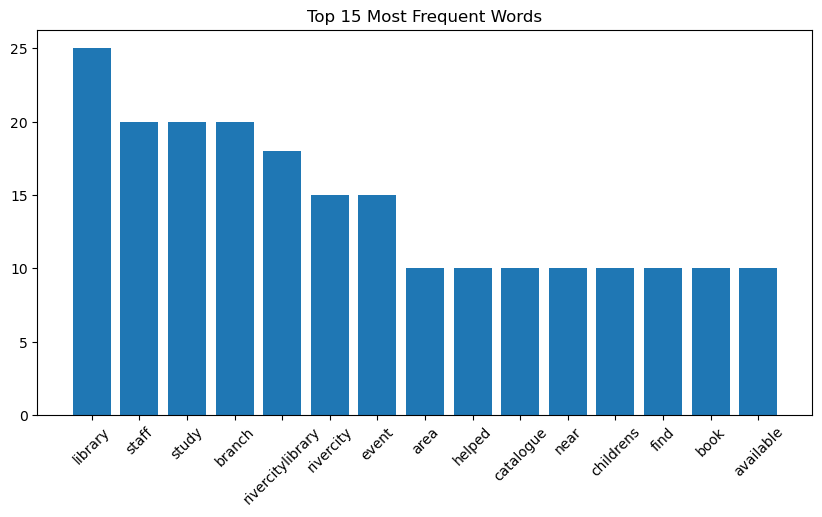

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(freq_df["Word"], freq_df["Frequency"])

plt.xticks(rotation=45)

plt.title("Top 15 Most Frequent Words")

plt.show()

The bar chart displays the 15 most frequent words in the cleaned patron messages. The most common word is "library", followed by words such as "staff", "study", "branch", "event", and "book". These words are directly related to the services provided by RiverCity Library and reflect the main topics discussed in patron requests. The frequent appearance of words suggests that patrons commonly ask about study spaces, library events, book availability, and staff assistance. This supports the business problem of automatically classifying service requests into different categories. Understanding the most common words helps identify key themes in the dataset and provides useful information for building an effective text classification model.

## Task 4: POS Tagging and Named Entity Recognition

In [26]:
examples = df["PatronMessage"].iloc[:3]

examples

0    The online newspaper portal worked perfectly a...
1    I liked the quiet study area in Markham; it he...
2    There was a strong noise from construction dur...
Name: PatronMessage, dtype: object

In [29]:
from nltk.tokenize import word_tokenize

from nltk import pos_tag

for text in examples:
    
    print(text)
    
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    
    print(tags)

The online newspaper portal worked perfectly after staff reset my password.
[('The', 'DT'), ('online', 'JJ'), ('newspaper', 'NN'), ('portal', 'NN'), ('worked', 'VBD'), ('perfectly', 'RB'), ('after', 'IN'), ('staff', 'NN'), ('reset', 'VB'), ('my', 'PRP$'), ('password', 'NN'), ('.', '.')]
I liked the quiet study area in Markham; it helped me prepare for my exam.
[('I', 'PRP'), ('liked', 'VBD'), ('the', 'DT'), ('quiet', 'JJ'), ('study', 'NN'), ('area', 'NN'), ('in', 'IN'), ('Markham', 'NNP'), (';', ':'), ('it', 'PRP'), ('helped', 'VBD'), ('me', 'PRP'), ('prepare', 'VB'), ('for', 'IN'), ('my', 'PRP$'), ('exam', 'NN'), ('.', '.')]
There was a strong noise from construction during my visit to RiverCity Library. #RiverCityLibrary
[('There', 'EX'), ('was', 'VBD'), ('a', 'DT'), ('strong', 'JJ'), ('noise', 'NN'), ('from', 'IN'), ('construction', 'NN'), ('during', 'IN'), ('my', 'PRP$'), ('visit', 'NN'), ('to', 'TO'), ('RiverCity', 'NNP'), ('Library', 'NNP'), ('.', '.'), ('#', '#'), ('RiverCityLib

1. The online newspaper portal worked perfectly after staff reset my password.

* Nouns: newspaper, portal, staff, password
* Verbs: worked, reset
* Adjective: online

* Named Entity Recognition (NER): No major named entities such as locations, organizations, or dates were detected.

* Business Value:
The nouns identify important service-related terms, while the verbs describe actions taken to resolve the issue. This information helps the library understand digital access requests and improve customer support services.

2. I liked the quiet study area in Markham; it helped me prepare for my exam.

* Nouns: study, area, exam
* Verbs: liked, helped, prepare
* Adjective: quiet

* Named Entity Recognition (NER): Markham was detected as a location (Geopolitical Entity).

* Business Value:
Identifying locations such as Markham helps the library understand where requests originate. The nouns and verbs reveal that the request is related to study facilities, which can help classify the message into the Study_Space category.

3. There was a strong noise from construction during my visit to RiverCity Library.

* Nouns: noise, construction, visit, RiverCity, Library
* Verb: was
* Adjective: strong

* Named Entity Recognition (NER): RiverCity Library may be recognized as an organization or library name.

* Business Value:
NER helps identify the specific library involved in the request. Words such as noise and construction indicate a facility-related issue, which can help route the request to the appropriate department for action.

## Task 5: Feature Extraction

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Text"])

print(X.shape)

(120, 153)


The TF-IDF feature matrix has a shape of (120, 153), which means there are 120 patron requests and 153 unique text features (words) extracted from the cleaned text. Each row represents one request, and each column represents a word weighted by its importance in the dataset.

#### Why Text Must Be Converted into Numbers

Machine learning algorithms cannot directly understand or process text data. They require numerical input to perform calculations and identify patterns. Therefore, text must be converted into numerical features before building a classification model. TF-IDF was used to transform patron messages into numbers. TF-IDF assigns higher weights to words that are important in a specific message but less common across all messages. This helps the model focus on meaningful words that distinguish different request categories. By converting text into numerical features, the machine learning model can learn relationships between words and request categories, allowing it to accurately classify future patron service requests.

## Task 6: Build a Text Classification Model

In [32]:
X = tfidf.fit_transform(df["Clean_Text"])

y = df["RequestCategory"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [35]:
y_pred = model.predict(X_test)

## Task 7: Model Evaluation

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

1.0


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3 0 0 0 0 0]
 [0 3 0 0 0 0]
 [0 0 8 0 0 0]
 [0 0 0 5 0 0]
 [0 0 0 0 4 0]
 [0 0 0 0 0 1]]


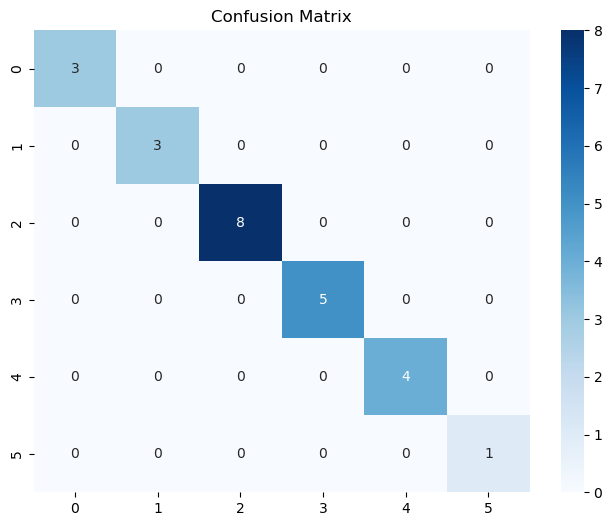

In [42]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

 Book_Availability       1.00      1.00      1.00         3
    Digital_Access       1.00      1.00      1.00         3
Event_Registration       1.00      1.00      1.00         8
    Facility_Issue       1.00      1.00      1.00         5
        Staff_Help       1.00      1.00      1.00         4
       Study_Space       1.00      1.00      1.00         1

          accuracy                           1.00        24
         macro avg       1.00      1.00      1.00        24
      weighted avg       1.00      1.00      1.00        24



#### What does the accuracy mean?

The model achieved an accuracy of 100%, meaning that all 24 test records were classified correctly. In other words, the model successfully predicted the correct request category for every patron message in the testing dataset.

#### Which Class Was Predicted Better?

All classes were predicted equally well. The categories Book_Availability, Digital_Access, Event_Registration, Facility_Issue, Staff_Help, and Study_Space each achieved precision, recall, and F1-score values of 1.00. This indicates that the model performed perfectly across all request categories.

#### What Type of Mistakes Did the Model Make?

According to the confusion matrix, the model did not make any classification errors. All predictions matched the actual categories, and there were no misclassified requests.

#### Why Could These Mistakes Matter for the Business?

Although no mistakes occurred in this test dataset, classification errors in a real-world environment could lead to requests being sent to the wrong department. For example, a Digital_Access issue might be incorrectly classified as Staff_Help, causing delays in resolving the patron's problem. Accurate classification is important because it improves response times, reduces staff workload, and enhances customer satisfaction.

## Task 8: Business Interpretation

#### What the model is trying to predict?
In this project, a text classification model was developed to automatically predict the category of public library service requests. The goal of the model was to classify patron messages into one of six categories: Book_Availability, Digital_Access, Event_Registration, Facility_Issue, Staff_Help, and Study_Space.

#### What dataset you used?
The dataset used was the Public Library Service Request Classification dataset, which contains patron service requests submitted through different channels. 

#### What text column and target variable you selected?
The PatronMessage column was selected as the text feature (X), while RequestCategory was used as the target variable (y).

#### What preprocessing steps you applied?
Several text preprocessing techniques were applied before building the model, including converting text to lowercase, removing punctuation, removing stopwords, tokenization, and lemmatization. These steps helped clean and standardize the text data for analysis.

For feature extraction, TF-IDF (Term Frequency–Inverse Document Frequency) was used to convert the text into numerical features. A Naive Bayes classifier was then trained using the processed text data.

#### What result you obtained?
The model achieved an accuracy of 100%, with perfect precision, recall, and F1-scores for all request categories. The confusion matrix also showed that all test records were classified correctly.

#### One business insight from the text data
One important business insight from the text analysis is that words such as library, staff, study, branch, event, and book appeared frequently in patron messages. This indicates that study spaces, library resources, staff assistance, and events are among the most common topics discussed by patrons and may require continued attention from library management.

#### One limitation of your model or dataset
One limitation of this project is that the dataset is relatively small, containing only 120 records. Because the dataset is limited and highly structured, the model's perfect performance may not fully represent how it would perform on larger or more diverse real-world library requests. Additional data would help improve the model's generalizability and robustness.

Overall, the NLP text classification model successfully automated the categorization of library service requests. This solution can help RiverCity Library improve operational efficiency, reduce manual workload, and provide faster responses to patrons by automatically routing requests to the appropriate department.